Cell ini menginstal library yang diperlukan dan mengunduh dataset dari Kaggle menggunakan `kagglehub`.

In [76]:
!pip install kagglehub Sastrawi streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.4 MB/s eta 0:00:00


Pada bagian ini, seluruh library yang dibutuhkan dalam proyek dipanggil. Library tersebut digunakan untuk mengolah data, membersihkan teks, membuat visualisasi, membangun model machine learning, mengevaluasi model, dan menyimpan model.

In [77]:
import os
import re
import glob
import json
import joblib
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import kagglehub

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

In [78]:
# Download dataset dari Kaggle
path = kagglehub.dataset_download(
    "alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia"
)

print("Path to dataset files:", path)
print("\nDaftar file dalam dataset:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'dana-app-sentiment-review-on-playstore-indonesia' dataset.
Path to dataset files: /kaggle/input/dana-app-sentiment-review-on-playstore-indonesia

Daftar file dalam dataset:
/kaggle/input/dana-app-sentiment-review-on-playstore-indonesia/review_dana_labelled.csv


 Data Understanding

Pada tahap ini dilakukan pemahaman awal terhadap dataset, meliputi:

- Membaca file dataset.
- Mengecek ukuran data.
- Mengecek nama kolom.
- Mengecek missing value dan duplikasi.
- Mendeteksi kolom review dan kolom label/rating.
- Melihat distribusi kelas sentimen.

In [79]:
# Membaca file CSV secara otomatis dari folder Kaggle
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSV files ditemukan:", csv_files)

if len(csv_files) == 0:
    raise FileNotFoundError("Tidak ada file CSV yang ditemukan. Cek kembali isi folder dataset.")

selected_csv = csv_files[0]
print("\nFile yang digunakan:", selected_csv)

try:
    df = pd.read_csv(selected_csv)
except Exception:
    df = pd.read_csv(selected_csv, sep=None, engine="python")

df.head()

CSV files ditemukan: ['/kaggle/input/dana-app-sentiment-review-on-playstore-indonesia/review_dana_labelled.csv']

File yang digunakan: /kaggle/input/dana-app-sentiment-review-on-playstore-indonesia/review_dana_labelled.csv


,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp saya buram jdi ga bisa verifikasi..trus coba lewat email di suruh nunggu ...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kaga ikhlas ngasih diskon nya,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no saldonya gk ada sama sekali dana tidak bertanggung jawab Buktinya saldo ...,NEGATIVE


In [80]:
print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())
print("\nInformasi dataset:")
df.info()

Ukuran dataset: (50000, 5)

Nama kolom:
['userName', 'score', 'at', 'content', 'sentimen']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  50000 non-null  object
 1   score     50000 non-null  int64 
 2   at        50000 non-null  object
 3   content   50000 non-null  object
 4   sentimen  50000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


In [81]:
print("Missing value per kolom:")
print(df.isnull().sum())
print("\nJumlah data duplikat:", df.duplicated().sum())

Missing value per kolom:
userName    0
score       0
at          0
content     0
sentimen    0
dtype: int64

Jumlah data duplikat: 0


Deteksi Kolom Review dan Label

Kode berikut dibuat fleksibel agar bisa menyesuaikan nama kolom pada dataset. Jika hasil deteksi tidak sesuai, ubah manual nilai `text_col`, `label_col`, atau `score_col`.

In [82]:
def find_column(columns, candidates):
    # Mencari nama kolom berdasarkan daftar kandidat.
    columns_lower = {col.lower(): col for col in columns}

    # Cari exact match terlebih dahulu.
    for candidate in candidates:
        if candidate.lower() in columns_lower:
            return columns_lower[candidate.lower()]

    # Jika tidak ada exact match, cari partial match.
    for col in columns:
        col_lower = col.lower()
        for candidate in candidates:
            if candidate.lower() in col_lower:
                return col
    return None

text_candidates = [
    "content", "review", "reviews", "ulasan", "komentar", "comment", "comments", "text", "body"
]
label_candidates = [
    "sentiment", "sentimen", "label", "polarity", "kategori", "category", "class", "target"
]
score_candidates = [
    "score", "rating", "ratings", "star", "stars", "bintang"
]

text_col = find_column(df.columns, text_candidates)
label_col = find_column(df.columns, label_candidates)
score_col = find_column(df.columns, score_candidates)

print("Kolom teks/review terdeteksi:", text_col)
print("Kolom label/sentimen terdeteksi:", label_col)
print("Kolom score/rating terdeteksi:", score_col)

# Jika hasil deteksi salah, ubah manual di sini. Contoh:
# text_col = "content"
# label_col = "sentiment"
# score_col = "score"

if text_col is None:
    raise ValueError("Kolom teks review tidak terdeteksi. Isi manual text_col sesuai nama kolom dataset.")

if label_col is None and score_col is None:
    raise ValueError("Kolom label/sentimen atau score/rating tidak ditemukan. Isi manual label_col atau score_col.")

Kolom teks/review terdeteksi: content
Kolom label/sentimen terdeteksi: sentimen
Kolom score/rating terdeteksi: score


In [83]:
# Menentukan sumber label: gunakan kolom label jika ada, jika tidak gunakan score/rating.
label_source_col = label_col if label_col is not None else score_col

work_df = df[[text_col, label_source_col]].copy()
work_df.columns = ["review", "label_source"]

print("Kolom review yang digunakan:", text_col)
print("Kolom sumber label yang digunakan:", label_source_col)
work_df.head()

Kolom review yang digunakan: content
Kolom sumber label yang digunakan: sentimen


,review,label_source
0,Bagus,POSITIVE
1,Dana mmg keren mantap.,POSITIVE
2,Saya ngajuin upgrade dana premium krna ktp saya buram jdi ga bisa verifikasi..trus coba lewat email di suruh nunggu ...,NEGATIVE
3,Kocak mana diskon nya ml malah eror segala kaga ikhlas ngasih diskon nya,NEGATIVE
4,Saldo hilang karena no lama Hilang ganti no saldonya gk ada sama sekali dana tidak bertanggung jawab Buktinya saldo ...,NEGATIVE


In [84]:
def score_to_sentiment(score):
    # Mengubah rating 1-5 menjadi sentimen.
    try:
        score = float(score)
    except Exception:
        return np.nan

    if score <= 2:
        return "negatif"
    elif score == 3:
        return "netral"
    elif score >= 4:
        return "positif"
    return np.nan


def text_to_sentiment(label):
    # Mengubah label teks/numerik menjadi format sentimen yang konsisten.
    label = str(label).lower().strip()

    if label in ["positive", "positif", "pos", "p"]:
        return "positif"
    if label in ["negative", "negatif", "neg", "n"]:
        return "negatif"
    if label in ["neutral", "netral", "neu"]:
        return "netral"

    # Mapping umum untuk label numerik 0, 1, 2.
    # Jika dataset kamu memakai mapping berbeda, ubah bagian ini.
    if label == "0":
        return "negatif"
    if label == "1":
        return "netral"
    if label == "2":
        return "positif"

    return label

# Membuat kolom sentiment.
if label_source_col == score_col:
    work_df["sentiment"] = work_df["label_source"].apply(score_to_sentiment)
else:
    if pd.api.types.is_numeric_dtype(work_df["label_source"]):
        unique_values = sorted(work_df["label_source"].dropna().unique())
        print("Unique numeric label:", unique_values[:20])

        # Jika nilainya 1-5, anggap sebagai rating.
        if len(unique_values) > 0 and min(unique_values) >= 1 and max(unique_values) <= 5:
            work_df["sentiment"] = work_df["label_source"].apply(score_to_sentiment)
        else:
            work_df["sentiment"] = work_df["label_source"].apply(text_to_sentiment)
    else:
        work_df["sentiment"] = work_df["label_source"].apply(text_to_sentiment)

# Ambil hanya label yang valid.
valid_sentiments = ["negatif", "netral", "positif"]
work_df = work_df[work_df["sentiment"].isin(valid_sentiments)].copy()

print("Jumlah data setelah label dibuat:", work_df.shape)
print("\nDistribusi sentimen:")
print(work_df["sentiment"].value_counts())
work_df.head()

Jumlah data setelah label dibuat: (50000, 3)

Distribusi sentimen:
sentiment
positif    26555
negatif    17073
netral      6372
Name: count, dtype: int64


,review,label_source,sentiment
0,Bagus,POSITIVE,positif
1,Dana mmg keren mantap.,POSITIVE,positif
2,Saya ngajuin upgrade dana premium krna ktp saya buram jdi ga bisa verifikasi..trus coba lewat email di suruh nunggu ...,NEGATIVE,negatif
3,Kocak mana diskon nya ml malah eror segala kaga ikhlas ngasih diskon nya,NEGATIVE,negatif
4,Saldo hilang karena no lama Hilang ganti no saldonya gk ada sama sekali dana tidak bertanggung jawab Buktinya saldo ...,NEGATIVE,negatif


Visualisasi 1: Distribusi Sentimen

Visualisasi ini penting untuk melihat apakah data sentimen seimbang atau tidak. Jika salah satu kelas terlalu dominan, hasil model bisa bias ke kelas tersebut.

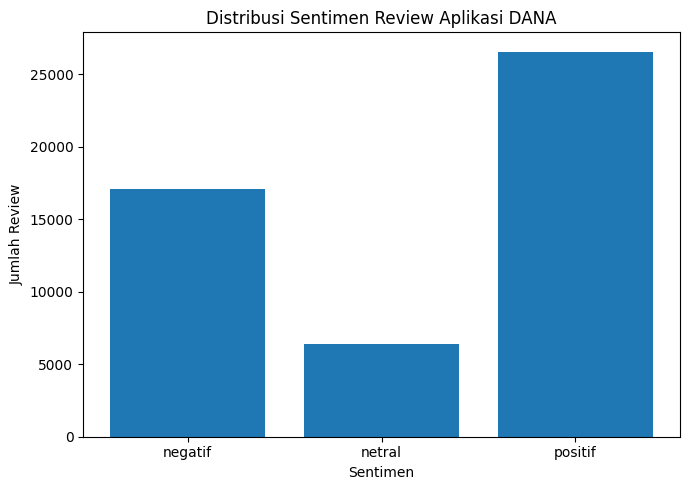

In [85]:
os.makedirs("images", exist_ok=True)

sentiment_order = [label for label in ["negatif", "netral", "positif"] if label in work_df["sentiment"].unique()]
sentiment_counts = work_df["sentiment"].value_counts().reindex(sentiment_order)

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Distribusi Sentimen Review Aplikasi DANA")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.savefig("images/01_distribusi_sentimen.png", dpi=300)
plt.show()


Data Preparation

Tahap ini mempersiapkan teks agar siap digunakan oleh model machine learning. Proses yang dilakukan:

1. Menghapus data kosong.
2. Menghapus review duplikat.
3. Case folding atau mengubah teks menjadi huruf kecil.
4. Menghapus URL, mention, hashtag, angka, simbol, dan tanda baca.
5. Normalisasi kata tidak baku.
6. Stopword removal, tetapi kata negasi seperti tidak, bukan, dan jangan tetap dipertahankan karena penting untuk sentimen.


In [86]:
before_shape = work_df.shape

work_df = work_df.dropna(subset=["review", "sentiment"])
work_df = work_df.drop_duplicates(subset=["review"])
work_df = work_df.reset_index(drop=True)

print("Ukuran sebelum cleaning:", before_shape)
print("Ukuran setelah hapus missing value dan duplikasi:", work_df.shape)

Ukuran sebelum cleaning: (50000, 3)
Ukuran setelah hapus missing value dan duplikasi: (31701, 3)


In [88]:
# Stopword bahasa Indonesia dari Sastrawi.
factory = StopWordRemoverFactory()
stopwords_indonesia = set(factory.get_stop_words())

# Kata negasi jangan dihapus karena sangat penting dalam analisis sentimen.
negation_words = {"tidak", "bukan", "jangan", "belum", "kurang", "tanpa", "ga", "gak", "nggak", "ngga"}
stopwords_indonesia = stopwords_indonesia - negation_words

# Stopword tambahan yang terlalu umum pada konteks review aplikasi.
custom_stopwords = {
    "dana", "aplikasi", "apk", "app", "playstore", "play", "store",
    "nya", "nih", "dong", "sih", "deh", "lah", "ya", "aja", "kak", "min", "admin"
}

all_stopwords = stopwords_indonesia.union(custom_stopwords)

# Normalisasi kata tidak baku/slang.
normalization_dict = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak", "gk": "tidak",
    "tdk": "tidak", "tak": "tidak", "yg": "yang", "dgn": "dengan", "utk": "untuk",
    "dlm": "dalam", "sm": "sama", "sma": "sama", "tp": "tapi", "tpi": "tapi",
    "krn": "karena", "dr": "dari", "blm": "belum", "sdh": "sudah", "udh": "sudah",
    "udah": "sudah", "bgt": "banget", "bgtt": "banget", "mantab": "mantap",
    "mantapp": "mantap", "lemot": "lambat", "eror": "error", "err": "error",
    "gabisa": "tidak bisa", "gagal": "gagal", "topup": "top up", "tf": "transfer"
}


def clean_text(text):
    # Membersihkan teks review.
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)       # hapus URL
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)        # hapus mention
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)        # hapus hashtag
    text = re.sub(r"[^a-zA-Z\s]", " ", text)           # hapus angka dan simbol
    text = re.sub(r"\s+", " ", text).strip()           # hapus spasi berlebih

    tokens = text.split()
    tokens = [normalization_dict.get(token, token) for token in tokens]
    tokens = [token for token in tokens if token not in all_stopwords and len(token) > 2]

    return " ".join(tokens)

work_df["clean_review"] = work_df["review"].apply(clean_text)
work_df = work_df[work_df["clean_review"].str.strip() != ""].copy()
work_df = work_df.reset_index(drop=True)

work_df[["review", "clean_review", "sentiment"]].head(10)


,review,clean_review,sentiment
0,Bagus,bagus,positif
1,Dana mmg keren mantap.,mmg keren mantap,positif
2,Saya ngajuin upgrade dana premium krna ktp saya buram jdi ga bisa verifikasi..trus coba lewat email di suruh nunggu ...,ngajuin upgrade premium krna ktp buram jdi tidak verifikasi trus coba lewat email suruh nunggu hri hri lebih msih gi...,negatif
3,Kocak mana diskon nya ml malah eror segala kaga ikhlas ngasih diskon nya,kocak mana diskon malah error segala kaga ikhlas ngasih diskon,negatif
4,Saldo hilang karena no lama Hilang ganti no saldonya gk ada sama sekali dana tidak bertanggung jawab Buktinya saldo ...,saldo hilang lama hilang ganti saldonya tidak sama sekali tidak bertanggung jawab buktinya saldo tidak saldo lama,negatif
5,mayan,mayan,positif
6,Udah gua hapus dana ya. ilang ya udah 1 juta lebih duwit gua.mf dana sayah buka orang kaya itu uang keringat sayah u...,gua hapus ilang juta lebih duwit gua sayah buka orang kaya uang keringat sayah uang halal,negatif
7,baik,baik,positif
8,"TOLONG UNTUK SISTEM KEAMANAN DI PERBAIKI. KALAU 1 ATAU 2 ORNG YG KE HACK WAJAR, MUNGKIN KETELEDORAN PENGGUNA. TAPI K...",sistem keamanan perbaiki kalau orng hack wajar mungkin keteledoran pengguna kalau banyak terkena hack berarti salah ...,netral
9,mempermudah transfer,mempermudah transfer,positif


In [89]:
print("Jumlah data akhir setelah preprocessing:", work_df.shape)
print("\nDistribusi sentimen akhir:")
print(work_df["sentiment"].value_counts())

Jumlah data akhir setelah preprocessing: (31330, 4)

Distribusi sentimen akhir:
sentiment
negatif    13974
positif    11463
netral      5893
Name: count, dtype: int64


Visualisasi 2: Top 20 Kata Setelah Cleaning

Visualisasi ini digunakan untuk melihat kata yang paling sering muncul setelah teks dibersihkan. Grafik ini membantu memahami isu umum dalam review, misalnya kata seperti saldo, transfer, error, atau verifikasi.

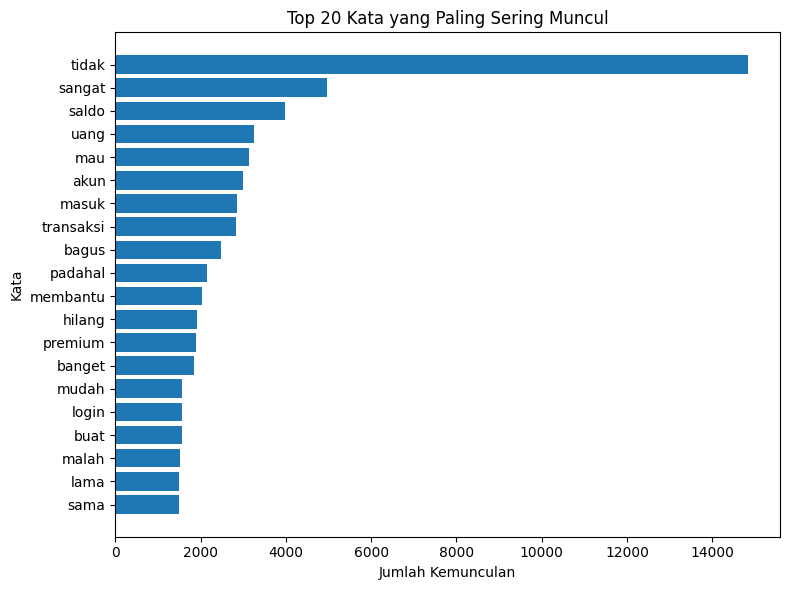

,kata,jumlah
0,tidak,14846
1,sangat,4958
2,saldo,3979
3,uang,3250
4,mau,3135
5,akun,2987
6,masuk,2858
7,transaksi,2831
8,bagus,2472
9,padahal,2159


In [90]:
all_words = " ".join(work_df["clean_review"]).split()
top_words = pd.DataFrame(Counter(all_words).most_common(20), columns=["kata", "jumlah"])

plt.figure(figsize=(8, 6))
plt.barh(top_words["kata"], top_words["jumlah"])
plt.title("Top 20 Kata yang Paling Sering Muncul")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Kata")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/02_top_20_kata.png", dpi=300)
plt.show()

top_words

Modeling

Pada tahap ini data dibagi menjadi data latih dan data uji. Kemudian dibangun dua model:

1. Naive Bayes dengan `MultinomialNB`.
2. SVM dengan `LinearSVC`.

Keduanya menggunakan TF-IDF sebagai ekstraksi fitur teks.

In [91]:
X = work_df["clean_review"]
y = work_df["sentiment"]

# Stratify digunakan jika setiap kelas memiliki minimal 2 data.
class_counts = y.value_counts()
stratify_y = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_y
)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test:", X_test.shape[0])
print("\nDistribusi label data train:")
print(y_train.value_counts())
print("\nDistribusi label data test:")
print(y_test.value_counts())

Jumlah data train: 25064
Jumlah data test: 6266

Distribusi label data train:
sentiment
negatif    11179
positif     9171
netral      4714
Name: count, dtype: int64

Distribusi label data test:
sentiment
negatif    2795
positif    2292
netral     1179
Name: count, dtype: int64


In [92]:
# Model 1: Naive Bayes.
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=1)),
    ("classifier", MultinomialNB(alpha=1.0))
])

# Model 2: SVM.
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=1)),
    ("classifier", LinearSVC(class_weight="balanced", max_iter=5000, random_state=42))
])

nb_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

print("Training model Naive Bayes dan SVM selesai.")

Training model Naive Bayes dan SVM selesai.


 Evaluation

Evaluasi model dilakukan menggunakan:

- Accuracy: seberapa banyak prediksi yang benar secara keseluruhan.
- Precision: ketepatan model ketika memprediksi suatu kelas.
- Recall: kemampuan model menemukan data aktual pada suatu kelas.
- F1-Score: keseimbangan antara precision dan recall.
- Confusion Matrix: melihat kelas mana yang sering salah diprediksi.

In [93]:
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

print("=== Classification Report: Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, zero_division=0, digits=4))

print("\n=== Classification Report: SVM ===")
print(classification_report(y_test, y_pred_svm, zero_division=0, digits=4))

=== Classification Report: Naive Bayes ===
              precision    recall  f1-score   support

     negatif     0.6909    0.9091    0.7851      2795
      netral     0.7407    0.1696    0.2761      1179
     positif     0.8451    0.8547    0.8499      2292

    accuracy                         0.7501      6266
   macro avg     0.7589    0.6445    0.6370      6266
weighted avg     0.7567    0.7501    0.7130      6266


=== Classification Report: SVM ===
              precision    recall  f1-score   support

     negatif     0.7980    0.7775    0.7876      2795
      netral     0.5740    0.5199    0.5456      1179
     positif     0.8311    0.8975    0.8630      2292

    accuracy                         0.7729      6266
   macro avg     0.7344    0.7316    0.7321      6266
weighted avg     0.7680    0.7729    0.7697      6266



In [94]:
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

metrics_df = pd.DataFrame([
    get_metrics(y_test, y_pred_nb, "Naive Bayes"),
    get_metrics(y_test, y_pred_svm, "SVM")
])

metrics_df_rounded = metrics_df.copy()
for col in metrics_df_rounded.columns[1:]:
    metrics_df_rounded[col] = metrics_df_rounded[col].round(4)

metrics_df_rounded

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0,Naive Bayes,0.7501,0.7589,0.6445,0.6370,0.7130
1,SVM,0.7729,0.7344,0.7316,0.7321,0.7697


Visualisasi 3: Perbandingan Performa Model

Grafik ini menjadi visualisasi utama untuk membandingkan performa Naive Bayes dan SVM.

<Figure size 900x500 with 0 Axes>

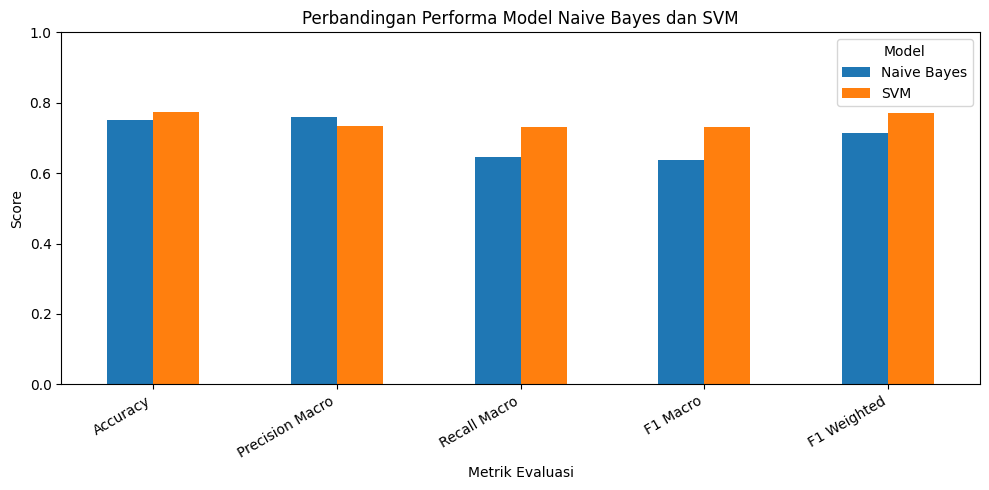

In [95]:
plot_df = metrics_df.set_index("Model")[["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "F1 Weighted"]]

plt.figure(figsize=(9, 5))
plot_df.T.plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan Performa Model Naive Bayes dan SVM")
plt.xlabel("Metrik Evaluasi")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("images/03_perbandingan_model.png", dpi=300)
plt.show()


In [96]:
best_row = metrics_df.sort_values(by="F1 Macro", ascending=False).iloc[0]
best_model_name = best_row["Model"]

if best_model_name == "SVM":
    best_model = svm_model
    best_pred = y_pred_svm
else:
    best_model = nb_model
    best_pred = y_pred_nb

print("Model terbaik berdasarkan F1 Macro:", best_model_name)
print(best_row)

Model terbaik berdasarkan F1 Macro: SVM
Model                   SVM
Accuracy           0.772901
Precision Macro    0.734366
Recall Macro        0.73162
F1 Macro           0.732079
F1 Weighted        0.769657
Name: 1, dtype: object


Visualisasi 4: Confusion Matrix Model Terbaik

Confusion matrix berikut digunakan untuk melihat detail prediksi benar dan salah dari model terbaik.

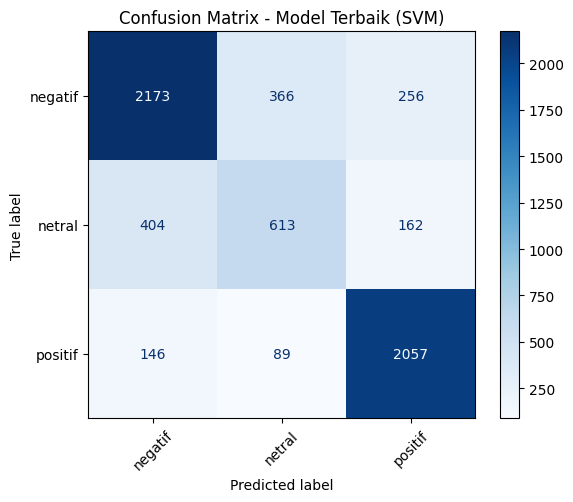

In [97]:
labels_order = [label for label in ["negatif", "netral", "positif"] if label in y_test.unique()]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    labels=labels_order,
    display_labels=labels_order,
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)
plt.title(f"Confusion Matrix - Model Terbaik ({best_model_name})")
plt.tight_layout()
plt.savefig("images/04_confusion_matrix_model_terbaik.png", dpi=300)
plt.show()

Testing Prediksi Manual

Cell ini digunakan untuk menguji model dengan input review baru.

In [98]:
def predict_sentiment(text, model=best_model):
    cleaned_text = clean_text(text)
    prediction = model.predict([cleaned_text])[0]
    return prediction

contoh_reviews = [
    "Aplikasi DANA sangat membantu, transfer cepat dan mudah digunakan.",
    "Saldo saya hilang dan aplikasi sering error saat transaksi.",
    "Aplikasinya biasa saja, kadang lancar kadang lambat."
]

for review in contoh_reviews:
    print("Review:", review)
    print("Cleaned:", clean_text(review))
    print("Prediksi:", predict_sentiment(review))
    print("-" * 80)

Review: Aplikasi DANA sangat membantu, transfer cepat dan mudah digunakan.
Cleaned: sangat membantu transfer cepat mudah digunakan
Prediksi: positif
--------------------------------------------------------------------------------
Review: Saldo saya hilang dan aplikasi sering error saat transaksi.
Cleaned: saldo hilang sering error transaksi
Prediksi: negatif
--------------------------------------------------------------------------------
Review: Aplikasinya biasa saja, kadang lancar kadang lambat.
Cleaned: aplikasinya biasa kadang lancar kadang lambat
Prediksi: negatif
--------------------------------------------------------------------------------


 Deployment Preparation

Tahap ini menyiapkan file yang diperlukan untuk deployment:

- models/best_model.pkl: model terbaik.
- models/model_naive_bayes.pkl: model Naive Bayes.
- models/model_svm.pk: model SVM.
- models/metrics_model.csv: hasil evaluasi model.
- app.py: aplikasi Streamlit sederhana.
- requirements.txt: daftar library yang dibutuhkan.
- README.md: draft laporan akhir untuk GitHub.

In [99]:
os.makedirs("models", exist_ok=True)
os.makedirs("images", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(nb_model, "models/model_naive_bayes.pkl")
joblib.dump(svm_model, "models/model_svm.pkl")
metrics_df_rounded.to_csv("models/metrics_model.csv", index=False)

metadata = {
    "best_model": best_model_name,
    "selection_metric": "F1 Macro",
    "labels": labels_order
}

with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("File model dan evaluasi berhasil disimpan.")

File model dan evaluasi berhasil disimpan.


In [100]:
app_code = r"""
import re
import json
import joblib
import streamlit as st

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except Exception:
    StopWordRemoverFactory = None

st.set_page_config(
    page_title="Analisis Sentimen DANA",
    page_icon="💬",
    layout="centered"
)

@st.cache_resource
def load_model():
    model = joblib.load("models/best_model.pkl")
    with open("models/metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    return model, metadata

model, metadata = load_model()

# Stopword dan normalisasi dibuat sama seperti notebook training.
if StopWordRemoverFactory is not None:
    factory = StopWordRemoverFactory()
    stopwords_indonesia = set(factory.get_stop_words())
else:
    stopwords_indonesia = {
        "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan", "atau",
        "pada", "adalah", "saya", "aku", "kamu", "dia", "mereka", "kami", "kita"
    }

negation_words = {"tidak", "bukan", "jangan", "belum", "kurang", "tanpa", "ga", "gak", "nggak", "ngga"}
stopwords_indonesia = stopwords_indonesia - negation_words

custom_stopwords = {
    "dana", "aplikasi", "apk", "app", "playstore", "play", "store",
    "nya", "nih", "dong", "sih", "deh", "lah", "ya", "aja", "kak", "min", "admin"
}
all_stopwords = stopwords_indonesia.union(custom_stopwords)

normalization_dict = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak", "gk": "tidak",
    "tdk": "tidak", "tak": "tidak", "yg": "yang", "dgn": "dengan", "utk": "untuk",
    "dlm": "dalam", "sm": "sama", "sma": "sama", "tp": "tapi", "tpi": "tapi",
    "krn": "karena", "dr": "dari", "blm": "belum", "sdh": "sudah", "udh": "sudah",
    "udah": "sudah", "bgt": "banget", "bgtt": "banget", "mantab": "mantap",
    "mantapp": "mantap", "lemot": "lambat", "eror": "error", "err": "error",
    "gabisa": "tidak bisa", "topup": "top up", "tf": "transfer"
}


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [normalization_dict.get(token, token) for token in tokens]
    tokens = [token for token in tokens if token not in all_stopwords and len(token) > 2]
    return " ".join(tokens)

st.title("Analisis Sentimen Review Aplikasi DANA")
st.write("Aplikasi ini memprediksi sentimen review pengguna DANA menggunakan model machine learning terbaik dari hasil evaluasi.")

st.info(f"Model yang digunakan: {metadata.get('best_model', 'Model terbaik')}")

user_input = st.text_area(
    "Masukkan review aplikasi DANA:",
    placeholder="Contoh: Aplikasi DANA sering error saat transfer saldo."
)

if st.button("Prediksi Sentimen"):
    if user_input.strip() == "":
        st.warning("Masukkan review terlebih dahulu.")
    else:
        cleaned = clean_text(user_input)
        prediction = model.predict([cleaned])[0]

        st.subheader("Hasil Prediksi")
        st.success(f"Sentimen: {prediction.upper()}")

        with st.expander("Lihat hasil preprocessing"):
            st.write(cleaned)
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("File app.py berhasil dibuat.")

File app.py berhasil dibuat.


In [101]:
requirements = """streamlit
pandas
numpy
scikit-learn
Sastrawi
joblib
matplotlib
kagglehub
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("File requirements.txt berhasil dibuat.")

File requirements.txt berhasil dibuat.


In [102]:
metrics_markdown = metrics_df_rounded.to_markdown(index=False)

readme_text = f"""# Analisis Sentimen Review Aplikasi DANA Menggunakan SVM dan Naive Bayes

## 1. Business Understanding
Project ini bertujuan untuk melakukan klasifikasi sentimen review pengguna aplikasi DANA berdasarkan data review Google Play Store. Analisis ini penting karena review pengguna dapat menggambarkan kepuasan, keluhan, serta pengalaman pengguna terhadap aplikasi.

## 2. Data Understanding
Dataset diperoleh dari Kaggle melalui `kagglehub` dengan nama dataset `alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia`.

Tahap data understanding mencakup pengecekan jumlah data, nama kolom, missing value, duplikasi, serta distribusi label sentimen.

## 3. Data Preparation
Tahap preprocessing yang dilakukan:
- Menghapus missing value.
- Menghapus data duplikat.
- Case folding.
- Menghapus URL, mention, hashtag, angka, simbol, dan tanda baca.
- Normalisasi kata tidak baku.
- Stopword removal dengan mempertahankan kata negasi seperti tidak, bukan, dan jangan.
- Ekstraksi fitur menggunakan TF-IDF.

## 4. Modeling
Model yang digunakan:
- Multinomial Naive Bayes.
- Linear Support Vector Machine / SVM.

## 5. Evaluation
Hasil evaluasi model:

{metrics_markdown}

Model terbaik berdasarkan Macro F1-Score adalah **{best_model_name}**.

## 6. Deployment
Deployment dilakukan menggunakan Streamlit. File utama deployment:
- `app.py`
- `requirements.txt`
- `models/best_model.pkl`
- `models/metadata.json`

Cara menjalankan aplikasi secara lokal:

```bash
streamlit run app.py
```

## 7. Kesimpulan
Model {best_model_name} dipilih sebagai model terbaik karena memiliki nilai Macro F1-Score tertinggi dibandingkan model lainnya. Model ini kemudian disimpan dan digunakan pada aplikasi deployment untuk memprediksi sentimen review baru.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README.md berhasil dibuat otomatis.")

README.md berhasil dibuat otomatis.


In [103]:
import os
import glob
import zipfile
from google.colab import files

# Cek file penting yang sudah dibuat
print("File yang ditemukan:")

target_files = []

# File utama deployment
for file in ["app.py", "requirements.txt", "README.md"]:
    if os.path.exists(file):
        target_files.append(file)
        print("✅", file)
    else:
        print("❌ Tidak ditemukan:", file)

# File model
model_files = glob.glob("model/*.pkl") + glob.glob("*.pkl") + glob.glob("model/*.joblib") + glob.glob("*.joblib")
for file in model_files:
    target_files.append(file)
    print("✅", file)

# File gambar visualisasi
image_files = glob.glob("images/*.png") + glob.glob("*.png") + glob.glob("images/*.jpg") + glob.glob("*.jpg")
for file in image_files:
    target_files.append(file)
    print("✅", file)

# Hilangkan duplikat
target_files = sorted(list(set(target_files)))

print("\nTotal file yang akan di-zip:", len(target_files))

File yang ditemukan:
✅ app.py
✅ requirements.txt
✅ README.md
✅ model/best_model.pkl
✅ model/hasil_evaluasi.pkl
✅ model/stopwords_indonesia.pkl
✅ images/04_confusion_matrix_model_terbaik.png
✅ images/03_perbandingan_model.png
✅ images/01_distribusi_sentimen.png
✅ images/02_top_20_kata.png
✅ wordcloud.png
✅ wordcloud_review_baru.png
✅ top_20_kata_baru.png
✅ top_words.png

Total file yang akan di-zip: 14


In [105]:
zip_name = "DANA_Sentiment_Project_Files.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in target_files:
        zipf.write(file)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>